# Heart rate extraction for ECG data

## Team late bloomers

| Name |  Email |
|------|-------|
| Aarni Kivelä | aarni.i.kivela@utu.fi |
| Jaakko Nurminen | jaakko.j.nurminen@utu.fi |
| Oliver Nielikäinen | oliver.e.nielikainen@utu.fi |

---

In [152]:
import os
# data management
import pickle
import numpy as np
# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# signal processing
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks, butter, filtfilt

# --- 1. Load ECG Data with HR Labels ---

In [153]:
file_path = os.path.join("data", "ecg_data_with_hr_labels.pkl")  

# Load ECG data
with open(file_path, "rb") as f:
    data = pickle.load(f)
    
# Extract signals and ground truth HR values
signals = data["signals"]
ground_truth_hr = data["hr_values"]

print(f"Loaded {len(signals)} ECG signals.")

Loaded 200 ECG signals.


### Visual inspection of the signal

<Axes: >

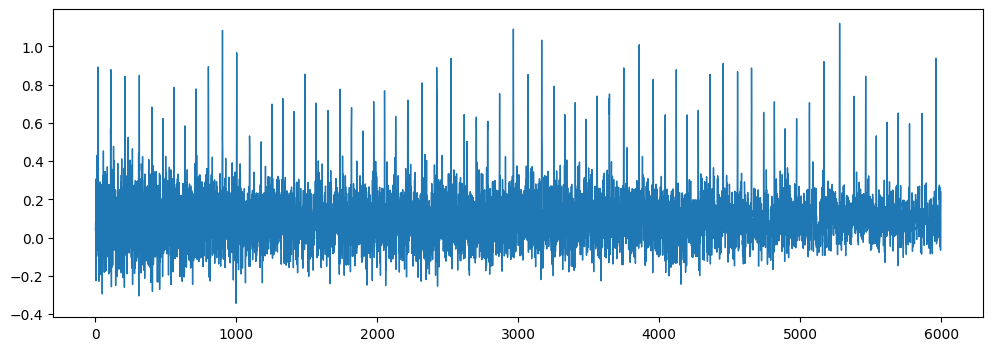

In [154]:
fig, axes = plt.subplots(1, 1, figsize=(12,4))

sns.lineplot(
    signals[1],
    color='tab:blue',
    linewidth=1
)

### Frequency domain

Visualize the data in the frequency domain such that, decision about bandpass filter range can be made.

Text(0.5, 0, 'Frequency (HZ)')

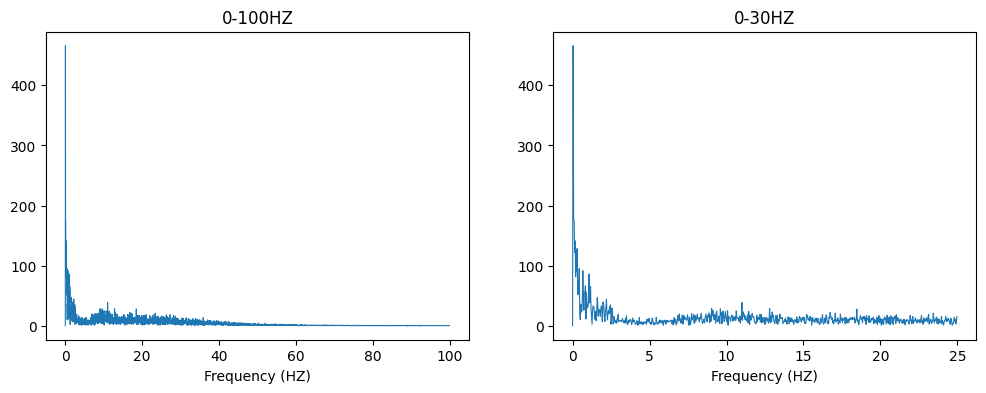

In [155]:
fs = 200
x = signals[3]
N = len(x)

x = x - np.mean(x)

T = 1 / fs

X = fft(x)

f = fftfreq(N, T)  # frequencies

fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.lineplot(ax=axes[0], x=f[:N//2], y=np.abs(X[:N//2]), linewidth=(0.8))

axes[0].set_title("0-100HZ")
axes[0].set_xlabel("Frequency (HZ)")

sns.lineplot(ax=axes[1], x=f[:N//8], y=np.abs(X[:N//8]), linewidth=(0.8)) # zoom for better analysis

axes[1].set_title("0-30HZ")
axes[1].set_xlabel("Frequency (HZ)")

In [156]:
f_cut_ecg=[0.5, 15.0]


# highpass & lowpass --> bandpass
def bandpass_filter(s, fs, fcut, order=4):
    nyq = fs / 2
    b, a = butter(order, [fcut[0]/nyq, fcut[1]/nyq], btype='band')
    return filtfilt(b, a, s)



def derivative_filter(ecg, fs):
    T = 1 / fs

    # 1D five-point stencil
    b = np.array([-1, -2, 0, 2, 1]) / (8 * T)
    
    #print(b)
    return filtfilt(b, [1], ecg)

def moving_average(ECG, N=30):
    
    window  = np.ones((1,N))/N
    ECG_ma  = np.convolve(np.squeeze(ECG),np.squeeze(window), mode='same')
    return ECG_ma

# --- 2. Implement Your HR Extraction Algorithm Here ---

**Instruction:**

***Your algorithm should return a list of HR values where each HR value corresponds to an ECG signal. Ensure the length of the list is 200 (equal to number of signals). The list can include np.nan if your algorithm is not able to calculate HR for a signal.***

Our idea is to just follow the typical Pan-Tompkins pipeline that is proven to work well enough in the field to HR extraction from ECG signal.

This article gives an simple overview into how Pan-Tompkins pipeline can be implemented:
https://medium.com/@cosmicwanderer/pan-tompkins-algorithm-for-detecting-qrs-waves-29c5f2927906

<div>
    <img src="Screenshot 2026-03-24 at 10.46.59.png">
</div>

In [157]:
def preprocess_ecg_signal(ecg_signals):
    """
    Signal preprocessing pipeline written on top of
    previous dummy hr extraction function.
    """
    detected_peaks = [np.nan] * 200  # Ensuring list has 200 elements 
    
    for i, signal in enumerate(ecg_signals):  

        bandpass = bandpass_filter(signal, fs, f_cut_ecg, order=4)

        derivative = derivative_filter(bandpass, fs)

        
        squared = derivative ** 2
        ma = moving_average(squared, N=30)

        peaks, props= find_peaks(
        ma,
        height=np.mean(ma),
        distance=int(0.3 * fs),
        prominence=0.2 * np.std(ma)
    )
        
        detected_peaks[i] = peaks  # Modify this with your method
    return detected_peaks



# Run your HR extraction algorithm
detected_peaks = preprocess_ecg_signal(signals)

In [158]:
def map_peaks_to_ecg(mwi_peaks, s, fs, search_ms=150):
    mapped_peaks = []
    half_window = int((search_ms / 1000) * fs)

    for p in mwi_peaks:
        start = max(p - half_window, 0)
        end   = min(p + half_window, len(s))
        local_max = np.argmax(s[start:end]) + start

        mapped_peaks.append(local_max)

    return np.array(mapped_peaks)


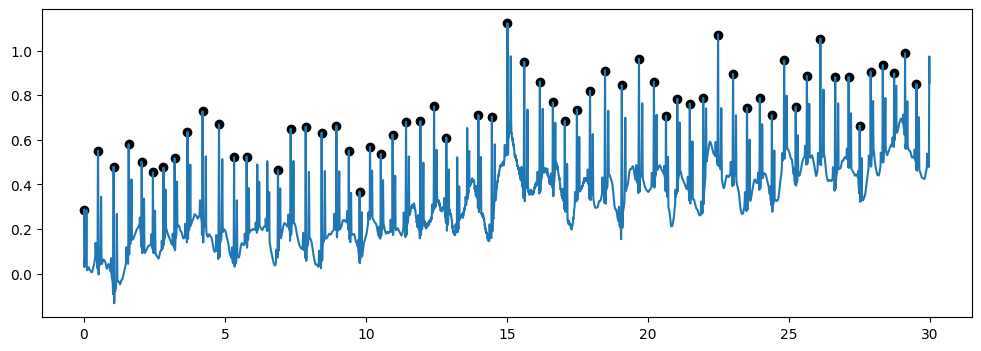

In [159]:
fig, axes = plt.subplots(1, 1, figsize=(12,4))

ecg_peaks = map_peaks_to_ecg(detected_peaks[3], signals[3], fs)
t = np.arange(len(signals[3])) / fs

plt.plot(t, signals[3])
plt.scatter(
    t[ecg_peaks],
    signals[3][ecg_peaks],
    color='black'
)

In [160]:
peaks_mapped = []

for peaks, signal in zip(detected_peaks, signals):
    ecg_peaks = map_peaks_to_ecg(peaks, signal, fs)
    peaks_mapped.append(ecg_peaks)

peak_counts = [len(peaks)*2 for peaks in peaks_mapped]

In [161]:
# Calculate HR using peaks

def extract_hr_w_intervals(signal_peak_ts):
    intervals = np.diff(signal_peak_ts)
    min_interval = 0.33
    max_interval = 1.5

    # Range filter
    valid = (intervals >= min_interval) & (intervals <= max_interval)
    filtered = intervals[valid]

    # Reject intervals > 2 std from median (handles gradual drift)
    median = np.median(filtered)
    std = np.std(filtered)
    filtered = filtered[np.abs(filtered - median) < 2 * std]

    avg_interval = np.mean(filtered)
    return 60 / avg_interval

signal_ts = np.arange(len(signals[3])) / fs
extracted_hr = []

for signal_peaks in peaks_mapped:
    signal_peak_times = []
    for peak_idx in signal_peaks:
        signal_peak_times.append(signal_ts[peak_idx])

    hr_estimate = extract_hr_w_intervals(signal_peak_times)
    extracted_hr.append(hr_estimate)

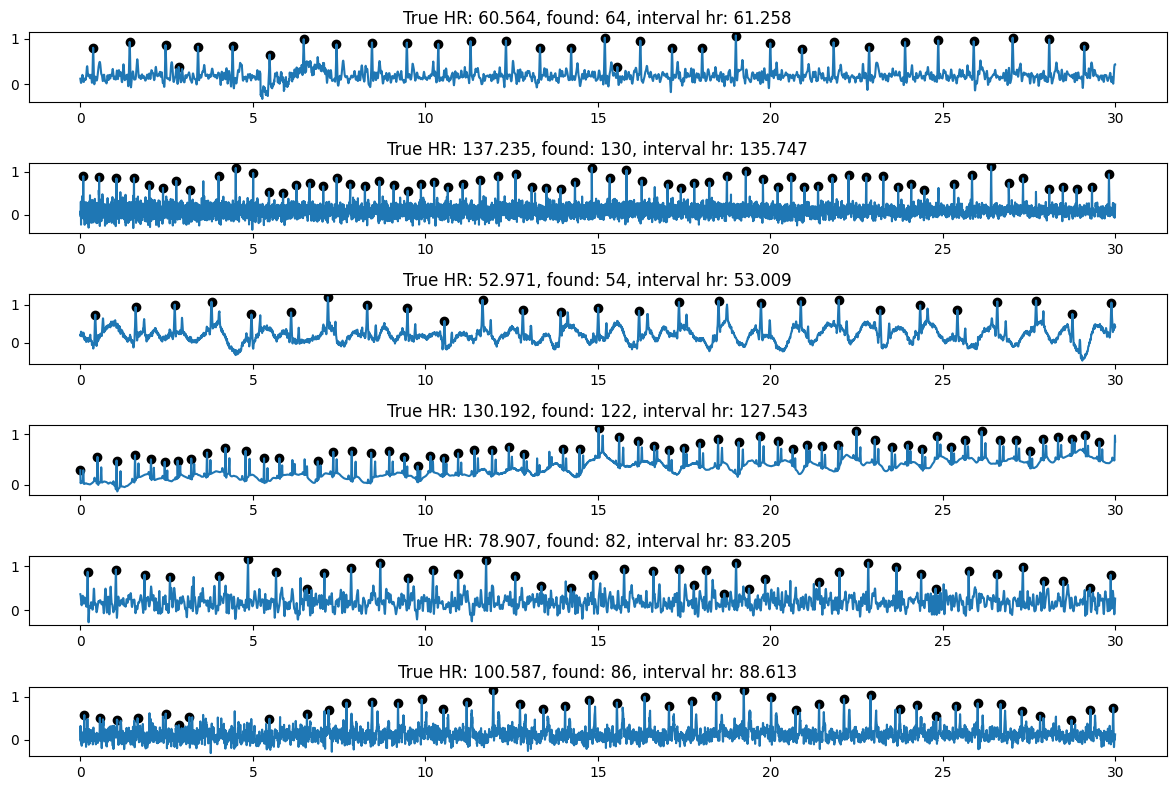

In [162]:
iters = 6
fig, axes = plt.subplots(iters, 1, figsize=(12,8))

for i in range(iters):
    
    peaks = peaks_mapped[i]
    
    axes[i].plot(t, signals[i])
    axes[i].scatter(
        t[peaks],
        signals[i][peaks],
        color='black'
    )
    
    axes[i].set_title(f"True HR: {ground_truth_hr[i]:.3f}, found: {len(peaks_mapped[i])*2}, interval hr: {extracted_hr[i]:.3f}")

plt.tight_layout()

# --- 3. Evaluation of HR Extraction Algorithm ---

**Description:**

***Evaluates the performance of your HR extraction method using Mean Absolute Error (MAE).***

In [163]:
def evaluate_hr_extraction(detected_hr_values, ground_truth_hr):
    """
    Evaluates HR extraction performance using Mean Absolute Error (MAE).
    
    Parameters:
        - detected_hr_values (List of floats): List of detected HR values.
        - ground_truth_hr (List of floats): List of ground truth HR values.
    
    Returns:
        - MAE score.
    """
    valid_indices = np.where(~np.isnan(detected_hr_values))[0].tolist() 
    
    if len(valid_indices) == 0:
        return {"Mean Absolute Error": np.nan}
    
    absolute_errors = np.abs(np.array(ground_truth_hr)[valid_indices] - np.array(detected_hr_values)[valid_indices])
    mae = np.sum(absolute_errors) / len(absolute_errors)
    return {"Mean Absolute Error": mae}

# Evaluate performance of your HR extraction method
mae = evaluate_hr_extraction(peak_counts, ground_truth_hr)
mae_interval = evaluate_hr_extraction(extracted_hr, ground_truth_hr)

print(mae)
print(mae_interval)

{'Mean Absolute Error': np.float64(7.539874538399278)}
{'Mean Absolute Error': np.float64(5.435474627870508)}


***Run the above cells and check your evaluation score.***

***The final assessment is based on the MAE, the lowest MAE is the first rank in competition!***

Seems like estimating heart rate improves significantly when using filtered intervals instead of just the peaks within the time segment. Especially this bit of code seemed to have great impact on the over all MAE.

```python
    # Reject intervals > 2 std from median (handles gradual drift)
    median = np.median(filtered)
    std = np.std(filtered)
    filtered = filtered[np.abs(filtered - median) < 2 * std]
```

This esentially filters out those intervals that aren't in the 95% confidence interval. Like pointed out in this [article](https://www.bmj.com/about-bmj/resources-readers/publications/statistics-square-one/4-statements-probability-and-confiden) if data point isn't within range of two standard deviations from the distribution mean it is most likely somekind of artifact.

With utilizing this we managed to get the **Mean Absolute Error** to 5.44